In [ ]:
!pip install wfdb pyentrp

import os
import wfdb
import numpy as np
import pandas as pd
from scipy.stats import skew, kurtosis
from pyentrp import entropy as ent

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 35.8 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.3 which is incompatible.
gradio 5.50.0 requires pandas<3.0,>=1.0, but you have pandas 3.0.3 which is incompatible.


In [ ]:
files_list = [
    'a01','a02','a03','a04','a05','a06','a07','a08','a09','a10',
    'a11','a12','a13','a14','a15','a16','a17','a18','a19','a20',
    'b01','b02','b03','b04','b05',
    'c01','c02','c03','c04','c05','c06','c07','c08','c09','c10'
]

In [ ]:
def extract_features(ecg_signal, fs=100):
    features = {}

    # Time-domain
    features['min'] = np.min(ecg_signal)
    features['max'] = np.max(ecg_signal)
    features['range'] = np.ptp(ecg_signal)
    features['median'] = np.median(ecg_signal)
    features['mean'] = np.mean(ecg_signal)
    features['std_dev'] = np.std(ecg_signal)
    features['skewness'] = skew(ecg_signal)
    features['kurtosis'] = kurtosis(ecg_signal)

    # Frequency-domain
    n = len(ecg_signal)
    fft_values = np.fft.fft(ecg_signal)
    freqs = np.fft.fftfreq(n, d=1/fs)
    power = np.abs(fft_values) ** 2

    mask = freqs >= 0
    freqs = freqs[mask]
    power = power[mask]

    vlf = np.sum(power[(freqs >= 0.0033) & (freqs < 0.04)])
    lf = np.sum(power[(freqs >= 0.04) & (freqs < 0.15)])
    hf = np.sum(power[(freqs >= 0.15) & (freqs < 0.4)])
    total = vlf + lf + hf

    features['vlf_power'] = vlf
    features['lf_power'] = lf
    features['hf_power'] = hf
    features['total_power'] = total
    features['lf_hf_ratio'] = lf / hf if hf != 0 else 0
    features['lfnu'] = (lf / total) * 100 if total != 0 else 0
    features['hfnu'] = (hf / total) * 100 if total != 0 else 0

    # Nonlinear
    try:
        features['perm_entropy'] = ent.permutation_entropy(ecg_signal, order=3, delay=1, normalize=True)
    except:
        features['perm_entropy'] = 0

    return features

In [ ]:
base_path = "/content/drive/MyDrive/data/apnea-ecg-database-1.0.0"

window_size = 6000   # 60 seconds
all_features = []

for record_name in files_list:
    print(f"Processing {record_name}...")

    try:
        record_path = os.path.join(base_path, record_name)

        # -------------------------
        # Load ECG
        # -------------------------
        record = wfdb.rdrecord(record_path)
        ecg_signal = record.p_signal[:, 0]

        # -------------------------
        # Load annotations
        # -------------------------
        ann = wfdb.rdann(record_path, "apn")
        labels = np.array(["N"] * len(ecg_signal))

        for i in range(len(ann.sample)):
            start = ann.sample[i]
            end = ann.sample[i+1] if i < len(ann.sample)-1 else len(ecg_signal)
            labels[start:end] = ann.symbol[i]

        # -------------------------
        # SEGMENT + FEATURE EXTRACTION
        # -------------------------
        for i in range(0, len(ecg_signal), window_size):

            ecg_segment = ecg_signal[i:i+window_size]
            label_segment = labels[i:i+window_size]

            if len(ecg_segment) == window_size and not np.any(np.isnan(ecg_segment)):

                features = extract_features(ecg_segment)

                # 🔥 IMPORTANT: Segment label (majority voting)
                apnea_count = np.sum(label_segment == 'A')
                normal_count = np.sum(label_segment == 'N')

                features['label'] = 1 if apnea_count > normal_count else 0
                features['record'] = record_name

                all_features.append(features)

    except Exception as e:
        print(f"❌ Error in {record_name}: {e}")

Processing a01...
Processing a02...
Processing a03...
Processing a04...
Processing a05...
Processing a06...
Processing a07...
Processing a08...
Processing a09...
Processing a10...
Processing a11...
Processing a12...
Processing a13...
Processing a14...
Processing a15...
Processing a16...
Processing a17...


/tmp/ipykernel_6581/2067902347.py:11: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  features['skewness'] = skew(ecg_signal)
/tmp/ipykernel_6581/2067902347.py:12: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  features['kurtosis'] = kurtosis(ecg_signal)


Processing a18...
Processing a19...
Processing a20...
Processing b01...
Processing b02...
Processing b03...
Processing b04...
Processing b05...
Processing c01...
Processing c02...
Processing c03...
Processing c04...
Processing c05...
Processing c06...
Processing c07...
Processing c08...
Processing c09...
Processing c10...


In [ ]:
df_final = pd.DataFrame(all_features)

output_path = "/content/drive/MyDrive/apnea_features_final.csv"
df_final.to_csv(output_path, index=False)

print("✅ DONE!")
print("Dataset shape:", df_final.shape)
print(df_final.head())

✅ DONE!
Dataset shape: (17068, 18)
     min    max  range  median      mean   std_dev  skewness   kurtosis  \
0 -0.885  1.750  2.635  -0.040 -0.000919  0.255151  2.823821  16.244233   
1 -0.900  1.740  2.640  -0.035  0.000766  0.268866  2.682191  14.860631   
2 -1.035  1.750  2.785  -0.030  0.000017  0.271984  2.486454  14.055261   
3 -1.170  1.845  3.015  -0.035 -0.000441  0.281247  1.920162  11.388732   
4 -1.035  1.700  2.735  -0.040  0.000551  0.267258  2.111700  11.644186   

   vlf_power    lf_power     hf_power  total_power  lf_hf_ratio       lfnu  \
0  21.449696  239.315401   266.242395   527.007492     0.898863  45.410246   
1  11.772572   63.788934   718.284196   793.845702     0.088807   8.035432   
2   4.253798  106.286533  1648.190633  1758.730963     0.064487   6.043365   
3  42.691853  122.039532   441.614130   606.345515     0.276349  20.127061   
4  19.803856  175.053180   612.518008   807.375045     0.285793  21.681768   

        hfnu  perm_entropy  label record  
0 

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import KFold, cross_val_score


In [ ]:
# Load your dataset
df = df_final.copy()

# --- FIX: Drop rows with NaN values ---
initial_shape = df.shape[0]
df = df.dropna()
print(f"Dropped {initial_shape - df.shape[0]} rows containing NaNs.")

# Features and labels
X = df.drop(columns=["label", "record"])
y = df["label"]

print("X shape:", X.shape)
print("y shape:", y.shape)

Dropped 20 rows containing NaNs.
X shape: (17048, 16)
y shape: (17048,)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
svm_model = SVC(kernel='rbf', C=1, gamma='scale')

svm_model.fit(X_train_scaled, y_train)

y_pred_svm = svm_model.predict(X_test_scaled)

print("=== SVM RESULTS ===")
print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_svm))

=== SVM RESULTS ===
Accuracy: 0.8149560117302053
              precision    recall  f1-score   support

           0       0.86      0.83      0.85      2104
           1       0.74      0.79      0.77      1306

    accuracy                           0.81      3410
   macro avg       0.80      0.81      0.81      3410
weighted avg       0.82      0.81      0.82      3410

Confusion Matrix:
 [[1747  357]
 [ 274 1032]]


In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("\n=== RANDOM FOREST RESULTS ===")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))


=== RANDOM FOREST RESULTS ===
Accuracy: 0.9005865102639297
              precision    recall  f1-score   support

           0       0.91      0.93      0.92      2104
           1       0.88      0.85      0.87      1306

    accuracy                           0.90      3410
   macro avg       0.90      0.89      0.89      3410
weighted avg       0.90      0.90      0.90      3410

Confusion Matrix:
 [[1958  146]
 [ 193 1113]]


In [ ]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

svm_model = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel='rbf', C=1, gamma='scale'))
])

svm_scores = cross_val_score(
    svm_model,
    X,
    y,
    cv=kf,
    scoring='accuracy'
)

print("=== SVM K-FOLD RESULTS ===")
print("Scores:", svm_scores)
print("Mean Accuracy:", np.mean(svm_scores))
print("Std Dev:", np.std(svm_scores))

=== SVM K-FOLD RESULTS ===
Scores: [0.82258065 0.81231672 0.80410557 0.8225286  0.81578175]
Mean Accuracy: 0.8154626574988235
Std Dev: 0.006922072963309874


In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_scores = cross_val_score(
    rf_model,
    X,
    y,
    cv=kf,
    scoring='accuracy'
)

print("\n=== RANDOM FOREST K-FOLD RESULTS ===")
print("Scores:", rf_scores)
print("Mean Accuracy:", np.mean(rf_scores))
print("Std Dev:", np.std(rf_scores))


=== RANDOM FOREST K-FOLD RESULTS ===
Scores: [0.89002933 0.89296188 0.89237537 0.89997067 0.90349076]
Mean Accuracy: 0.8957655989105945
Std Dev: 0.005091562895891987


In [ ]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
import numpy as np

SVM Fold 1 Accuracy: 0.8226
SVM Fold 2 Accuracy: 0.8123
SVM Fold 3 Accuracy: 0.8041
SVM Fold 4 Accuracy: 0.8225
SVM Fold 5 Accuracy: 0.8158


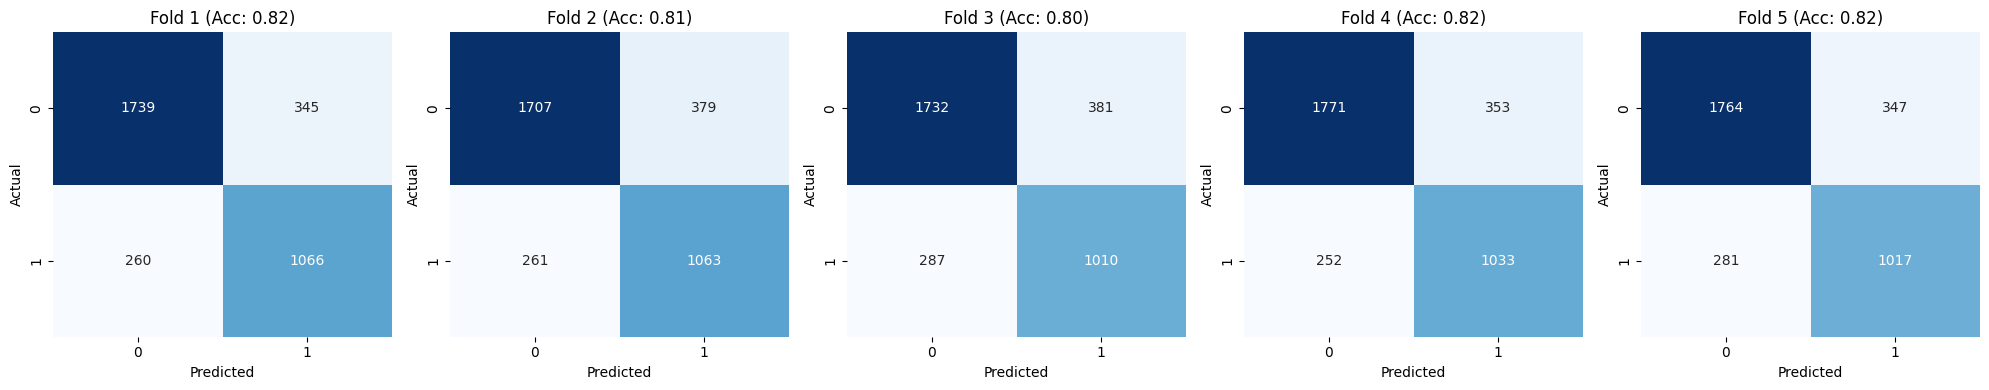


Average SVM Accuracy: 0.8155


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

svm_conf_matrices = []
svm_accuracies = []

fold = 1
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for (train_idx, test_idx), ax in zip(kf.split(X, y), axes.flatten()):

    # Use .iloc to avoid index label mismatch (KeyError)
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    # Scaling inside fold
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    model = SVC(kernel='rbf', C=1, gamma='scale')
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)

    svm_accuracies.append(acc)
    svm_conf_matrices.append(cm)

    # Plotting confusion matrix for each fold
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False)
    ax.set_title(f'Fold {fold} (Acc: {acc:.2f})')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

    print(f"SVM Fold {fold} Accuracy: {acc:.4f}")
    fold += 1

plt.tight_layout()
plt.show()

print(f"\nAverage SVM Accuracy: {np.mean(svm_accuracies):.4f}")

Random Forest Fold 1 Accuracy: 0.8900
Random Forest Fold 2 Accuracy: 0.8930
Random Forest Fold 3 Accuracy: 0.8924
Random Forest Fold 4 Accuracy: 0.9000
Random Forest Fold 5 Accuracy: 0.9035


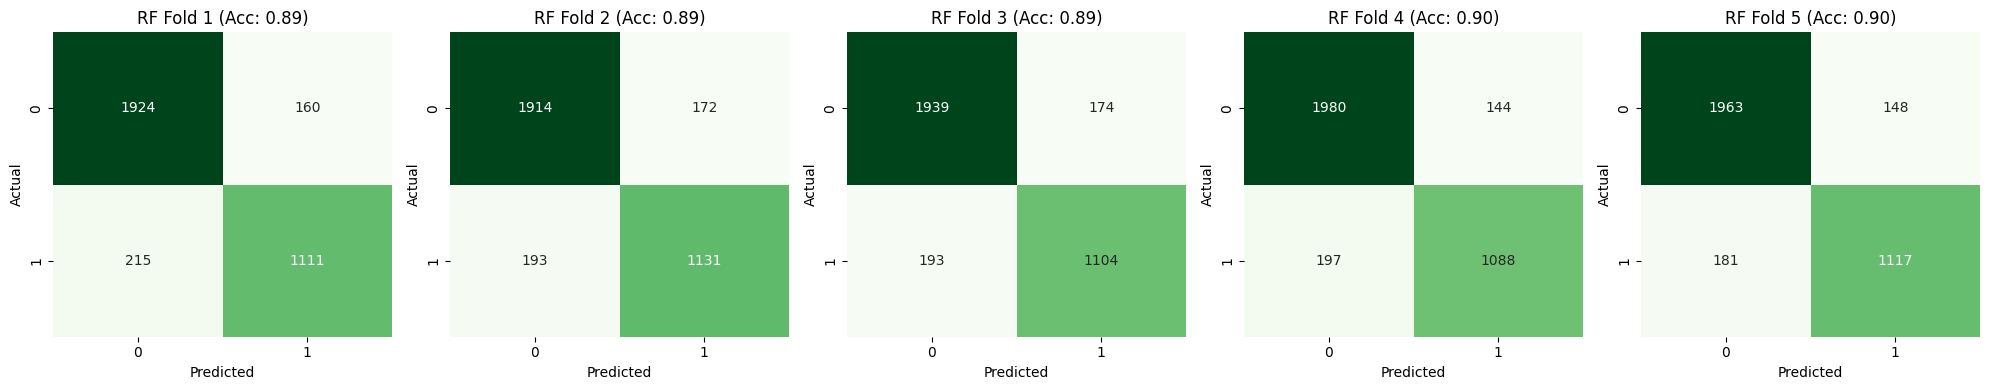


Average Random Forest Accuracy: 0.8958


In [ ]:
rf_conf_matrices = []
rf_accuracies = []

fold = 1
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for (train_idx, test_idx), ax in zip(kf.split(X, y), axes.flatten()):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    # Random Forest usually doesn't strictly require scaling,
    # but we use it here for consistency or use the raw X
    model = RandomForestClassifier(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)

    rf_accuracies.append(acc)
    rf_conf_matrices.append(cm)

    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', ax=ax, cbar=False)
    ax.set_title(f'RF Fold {fold} (Acc: {acc:.2f})')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

    print(f"Random Forest Fold {fold} Accuracy: {acc:.4f}")
    fold += 1

plt.tight_layout()
plt.show()

print(f"\nAverage Random Forest Accuracy: {np.mean(rf_accuracies):.4f}")